In [235]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
import pathlib
import gc
import warnings
warnings.filterwarnings('ignore')

ROOT = pathlib.Path().resolve()
DATA_FOLDER = ROOT / "data/bike"

print(DATA_FOLDER)


C:\Users\PatCa\Documents\PythonScripts\test_projects\big_data\bike_data\data\bike


## 2. EDA

In [236]:
df = pd.read_parquet(DATA_FOLDER / "pandas_full_2019.parquet")
display(df.head(5))
#df.isnull().sum()

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station longitude,end station latitude,bikeid,usertype,birth year,gender
0,320,2019-01-01 00:01:47.401,2019-01-01 00:07:07.581,3160,Central Park West & W 76 St,40.778969,-73.973747,3283,W 89 St & Columbus Ave,40.788219,-73.970413,15839,Subscriber,1971,1
1,316,2019-01-01 00:04:43.736,2019-01-01 00:10:00.608,519,Pershing Square North,40.751873,-73.977707,518,E 39 St & 2 Ave,40.747803,-73.973442,32723,Subscriber,1964,1
2,591,2019-01-01 00:06:03.997,2019-01-01 00:15:55.438,3171,Amsterdam Ave & W 82 St,40.785248,-73.976677,3154,E 77 St & 3 Ave,40.773144,-73.958565,27451,Subscriber,1987,1
3,2719,2019-01-01 00:07:03.545,2019-01-01 00:52:22.650,504,1 Ave & E 16 St,40.732220,-73.981659,3709,W 15 St & 6 Ave,40.738045,-73.996429,21579,Subscriber,1990,1
4,303,2019-01-01 00:07:35.945,2019-01-01 00:12:39.502,229,Great Jones St,40.727436,-73.993790,503,E 20 St & Park Ave,40.738274,-73.987518,35379,Subscriber,1979,1


In [237]:
# Summary statistics
trip_count = df.tripduration.count()
print(f'trip count: {trip_count}')
ave_trip_duration = df.tripduration.mean()
print(f'average trip duration: {round(ave_trip_duration/60,2)} min')
sub_tot = (df.usertype == 'Subscriber').sum()
cust_tot = (df.usertype == 'Customer').sum()
print(f'Number of subscribers: {sub_tot}, number of customers: {cust_tot}, total: {sub_tot+cust_tot}')
trips_by_unknown = (df.gender == 0).count()
trips_by_men = (df.gender == 1).count()
trips_by_women = (df.gender == 2).count()
print(f'Trips by men: {trips_by_men}, Trips by women: {trips_by_women}, total: {trips_by_unknown+trips_by_men+trips_by_women}')
ave_age = (df['birth year'].mean())
print(f'average age: {round(2019 - ave_age,0)} years')
mode_station_id = (df['start station id'].mode())
print(f'station id mode: {mode_station_id[0]}')
print(df[df['start station id'] == 519]['tripduration'].count())


trip count: 20551517
average trip duration: 16.3 min
Number of subscribers: 17679393, number of customers: 2872124, total: 20551517
Trips by men: 20551517, Trips by women: 20551517, total: 61654551
average age: 39.0 years
station id mode: 519
156575


In [238]:
# Trip duration
#converting trip duration from seconds to minuits
df['tripduration'] = df['tripduration']/60

#creating bins (0-30min, 30-60min, 60-120min, 120 and above)
max_limit = df['tripduration'].max()
print(max_limit)

63544.433333333334


In [239]:
bins = [0, 5, 10, 20, 30, 60, max_limit]
labels = [0,1,2,3,4,5]
df['tripduration_bins'] = pd.cut(df['tripduration'], bins=bins, labels=labels)
display(df.head(5))


,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station longitude,end station latitude,bikeid,usertype,birth year,gender,tripduration_bins
0,5.333333,2019-01-01 00:01:47.401,2019-01-01 00:07:07.581,3160,Central Park West & W 76 St,40.778969,-73.973747,3283,W 89 St & Columbus Ave,40.788219,-73.970413,15839,Subscriber,1971,1,1
1,5.266667,2019-01-01 00:04:43.736,2019-01-01 00:10:00.608,519,Pershing Square North,40.751873,-73.977707,518,E 39 St & 2 Ave,40.747803,-73.973442,32723,Subscriber,1964,1,1
2,9.850000,2019-01-01 00:06:03.997,2019-01-01 00:15:55.438,3171,Amsterdam Ave & W 82 St,40.785248,-73.976677,3154,E 77 St & 3 Ave,40.773144,-73.958565,27451,Subscriber,1987,1,1
3,45.316667,2019-01-01 00:07:03.545,2019-01-01 00:52:22.650,504,1 Ave & E 16 St,40.732220,-73.981659,3709,W 15 St & 6 Ave,40.738045,-73.996429,21579,Subscriber,1990,1,4
4,5.050000,2019-01-01 00:07:35.945,2019-01-01 00:12:39.502,229,Great Jones St,40.727436,-73.993790,503,E 20 St & Park Ave,40.738274,-73.987518,35379,Subscriber,1979,1,1


In [240]:
trip_duration_ = df.groupby(by=['tripduration_bins'])['tripduration'].count()/df.shape[0]
#display(trip_duration_.head(4))

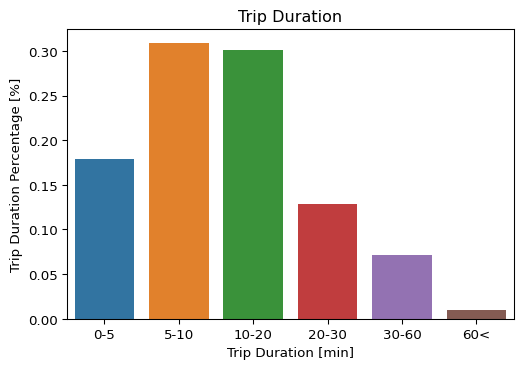

In [241]:

time_list = ['0-5', '5-10','10-20', '20-30','30-60','60<']
plt.figure(dpi=96)
sns.barplot(trip_duration_.index, trip_duration_.values)
plt.xticks(trip_duration_.index, time_list)
plt.title('Trip Duration')
plt.xlabel('Trip Duration [min]')
plt.ylabel('Trip Duration Percentage [%]')
plt.show()


In [242]:
# Age variations
df['age'] = 2019 - df['birth year']
bins = [0,18, 25, 35, 50, 65, 200]
labels = [0,1,2,3,4,5]
df['age_bucket'] = pd.cut(df['age'], bins=bins, labels=labels)
display(df.head(5))

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station longitude,end station latitude,bikeid,usertype,birth year,gender,tripduration_bins,age,age_bucket
0,5.333333,2019-01-01 00:01:47.401,2019-01-01 00:07:07.581,3160,Central Park West & W 76 St,40.778969,-73.973747,3283,W 89 St & Columbus Ave,40.788219,-73.970413,15839,Subscriber,1971,1,1,48,3
1,5.266667,2019-01-01 00:04:43.736,2019-01-01 00:10:00.608,519,Pershing Square North,40.751873,-73.977707,518,E 39 St & 2 Ave,40.747803,-73.973442,32723,Subscriber,1964,1,1,55,4
2,9.850000,2019-01-01 00:06:03.997,2019-01-01 00:15:55.438,3171,Amsterdam Ave & W 82 St,40.785248,-73.976677,3154,E 77 St & 3 Ave,40.773144,-73.958565,27451,Subscriber,1987,1,1,32,2
3,45.316667,2019-01-01 00:07:03.545,2019-01-01 00:52:22.650,504,1 Ave & E 16 St,40.732220,-73.981659,3709,W 15 St & 6 Ave,40.738045,-73.996429,21579,Subscriber,1990,1,4,29,2
4,5.050000,2019-01-01 00:07:35.945,2019-01-01 00:12:39.502,229,Great Jones St,40.727436,-73.993790,503,E 20 St & Park Ave,40.738274,-73.987518,35379,Subscriber,1979,1,1,40,3


age_bucket
0    0.004857
1    0.110696
2    0.365986
3    0.352816
4    0.146654
5    0.018992
Name: tripduration, dtype: float64

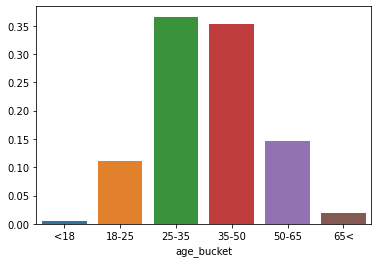

In [243]:
age_ow = df.groupby(by=['age_bucket'], axis=0)['tripduration'].count()/df.shape[0]
display(age_ow)

tick_labels = ['<18', '18-25', '25-35', '35-50', '50-65', '65<']
plt.figure()
sns.barplot(age_ow.index, age_ow.values)
#sns.displot(age_ow, x=age_ow.values, kind="kde")
plt.xticks(age_ow.index,tick_labels)
plt.show()

In [244]:
# Weekly variations
df['start_day'] = df['starttime'].dt.day_name()
display(df.head(8))

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station longitude,end station latitude,bikeid,usertype,birth year,gender,tripduration_bins,age,age_bucket,start_day
0,5.333333,2019-01-01 00:01:47.401,2019-01-01 00:07:07.581,3160,Central Park West & W 76 St,40.778969,-73.973747,3283,W 89 St & Columbus Ave,40.788219,-73.970413,15839,Subscriber,1971,1,1,48,3,Tuesday
1,5.266667,2019-01-01 00:04:43.736,2019-01-01 00:10:00.608,519,Pershing Square North,40.751873,-73.977707,518,E 39 St & 2 Ave,40.747803,-73.973442,32723,Subscriber,1964,1,1,55,4,Tuesday
2,9.850000,2019-01-01 00:06:03.997,2019-01-01 00:15:55.438,3171,Amsterdam Ave & W 82 St,40.785248,-73.976677,3154,E 77 St & 3 Ave,40.773144,-73.958565,27451,Subscriber,1987,1,1,32,2,Tuesday
3,45.316667,2019-01-01 00:07:03.545,2019-01-01 00:52:22.650,504,1 Ave & E 16 St,40.732220,-73.981659,3709,W 15 St & 6 Ave,40.738045,-73.996429,21579,Subscriber,1990,1,4,29,2,Tuesday
4,5.050000,2019-01-01 00:07:35.945,2019-01-01 00:12:39.502,229,Great Jones St,40.727436,-73.993790,503,E 20 St & Park Ave,40.738274,-73.987518,35379,Subscriber,1979,1,1,40,3,Tuesday
5,8.916667,2019-01-01 00:08:33.179,2019-01-01 00:17:28.354,3630,Frederick Douglass Blvd & W 115 St,40.803864,-73.955933,3529,Lenox Ave & W 130 St,40.810791,-73.943069,30315,Subscriber,1989,2,1,30,2,Tuesday
6,4.666667,2019-01-01 00:09:21.006,2019-01-01 00:14:01.151,3675,3 Ave & E 95 St,40.784595,-73.949684,3288,E 88 St & 1 Ave,40.778301,-73.948814,35391,Subscriber,1987,1,0,32,2,Tuesday
7,25.783333,2019-01-01 00:11:22.907,2019-01-01 00:37:10.055,285,Broadway & E 14 St,40.734547,-73.990738,3358,Garfield Pl & 8 Ave,40.671196,-73.974838,35551,Subscriber,1981,1,3,38,3,Tuesday


Monday       0.142183
Tuesday      0.153659
Wednesday    0.153111
Thursday     0.146034
Friday       0.151707
Saturday     0.136985
Sunday       0.116322
Name: start_day, dtype: float64

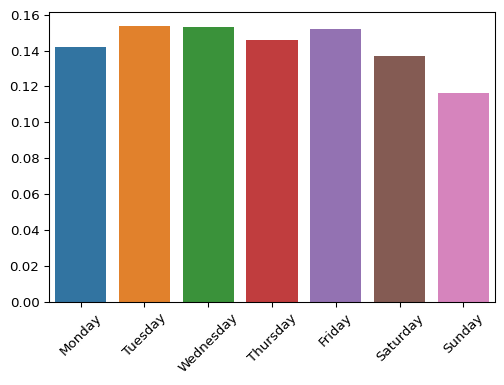

In [245]:
week_day_ave = df['start_day'].value_counts(normalize=1)
week_list = ['Monday', 'Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
week_day_ave = week_day_ave.reindex(week_list)
display(week_day_ave)

plt.figure(dpi=96)
sns.barplot(week_day_ave.index, week_day_ave.values)
plt.xticks(rotation=45)
plt.show()

In [246]:
week_day_count_ave = df['start_day'].value_counts()
display(week_day_count_ave)

Tuesday      3157924
Wednesday    3146663
Friday       3117804
Thursday     3001212
Monday       2922080
Saturday     2815248
Sunday       2390586
Name: start_day, dtype: int64

In [247]:
# Daily variations
df['hour'] = df['starttime'].dt.hour
display(df.head(5))

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station longitude,end station latitude,bikeid,usertype,birth year,gender,tripduration_bins,age,age_bucket,start_day,hour
0,5.333333,2019-01-01 00:01:47.401,2019-01-01 00:07:07.581,3160,Central Park West & W 76 St,40.778969,-73.973747,3283,W 89 St & Columbus Ave,40.788219,-73.970413,15839,Subscriber,1971,1,1,48,3,Tuesday,0
1,5.266667,2019-01-01 00:04:43.736,2019-01-01 00:10:00.608,519,Pershing Square North,40.751873,-73.977707,518,E 39 St & 2 Ave,40.747803,-73.973442,32723,Subscriber,1964,1,1,55,4,Tuesday,0
2,9.850000,2019-01-01 00:06:03.997,2019-01-01 00:15:55.438,3171,Amsterdam Ave & W 82 St,40.785248,-73.976677,3154,E 77 St & 3 Ave,40.773144,-73.958565,27451,Subscriber,1987,1,1,32,2,Tuesday,0
3,45.316667,2019-01-01 00:07:03.545,2019-01-01 00:52:22.650,504,1 Ave & E 16 St,40.732220,-73.981659,3709,W 15 St & 6 Ave,40.738045,-73.996429,21579,Subscriber,1990,1,4,29,2,Tuesday,0
4,5.050000,2019-01-01 00:07:35.945,2019-01-01 00:12:39.502,229,Great Jones St,40.727436,-73.993790,503,E 20 St & Park Ave,40.738274,-73.987518,35379,Subscriber,1979,1,1,40,3,Tuesday,0


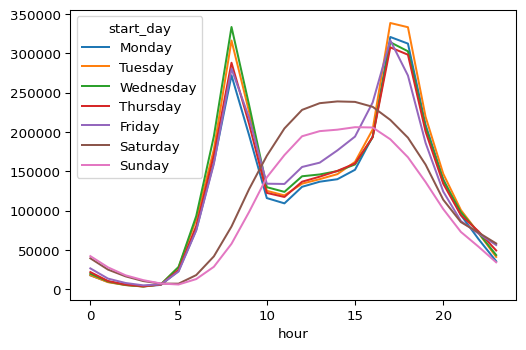

In [248]:
day_hour_ave = df.groupby(by=['start_day','hour'])['tripduration'].count()
day_hour_ave = day_hour_ave.reindex(week_list, level=0)
#display(day_hour_ave.head(5))

plt.figure(dpi=96)
sns.lineplot(x='hour', y=day_hour_ave.values, data=day_hour_ave, hue='start_day')
plt.show()

In [249]:
# Yearly variations
df['day_of_year'] = df['starttime'].dt.dayofyear
df['date'] = df['starttime'].dt.date
trips_per_day = df.groupby(by=['day_of_year']).agg(
    count_trips = pd.NamedAgg(column='tripduration', aggfunc='count'),
    weekday = pd.NamedAgg(column='start_day', aggfunc=lambda x: pd.Series.mode(x)[0]),
    DATE = pd.NamedAgg(column='date', aggfunc=lambda x: pd.Series.mode(x)[0]))

trips_per_day["DATE"] = trips_per_day["DATE"].astype(str)
display(trips_per_day.dtypes, trips_per_day.head(4))


count_trips     int64
weekday        object
DATE           object
dtype: object

,count_trips,weekday,DATE
day_of_year,,,
1,21962,Tuesday,2019-01-01
2,37797,Wednesday,2019-01-02
3,41676,Thursday,2019-01-03
4,43922,Friday,2019-01-04


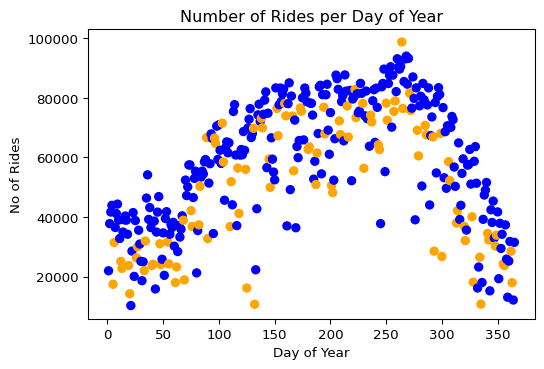

In [250]:

weekend_col = {'Monday':'blue','Tuesday':'blue', 'Wednesday':'blue', 'Thursday':'blue', 'Friday':'blue', 'Saturday':'orange', 'Sunday':'orange'}

plt.figure(dpi=96)
plt.scatter(trips_per_day.index, trips_per_day.count_trips, color=trips_per_day.weekday.map(weekend_col))
plt.title('Number of Rides per Day of Year')
plt.xlabel('Day of Year')
plt.ylabel('No of Rides')
plt.show()

# Check weather dependence

In [251]:
# Get weather data and join with daily riders
ghcn = pd.read_csv('data/weather/2019_clean.csv')
ghcn = ghcn.drop(columns=['Unnamed: 0'])
ghcn['DATE'] = ghcn['DATE'].astype(str)
display(ghcn.dtypes, ghcn.head(5))

DATE          object
AWND         float64
PRCP         float64
SNOW         float64
SNWD         float64
TMAX         float64
TMIN         float64
fog            int64
heavy_fog      int64
sleet          int64
haze           int64
fsh            int64
dtype: object

,DATE,AWND,PRCP,SNOW,SNWD,TMAX,TMIN,fog,heavy_fog,sleet,haze,fsh
0,2019-01-01,0.0,0.06,0.0,0.0,14.4,3.9,1,0,0,0,1
1,2019-01-02,0.0,0.00,0.0,0.0,4.4,1.7,0,0,0,0,0
2,2019-01-03,0.0,0.00,0.0,0.0,6.7,2.8,0,0,0,0,0
3,2019-01-04,0.0,0.00,0.0,0.0,8.3,1.7,0,0,0,0,0
4,2019-01-05,0.0,0.50,0.0,0.0,8.3,5.0,1,0,0,0,1


In [252]:
trips_per_day = pd.merge(trips_per_day, ghcn, how="left", on='DATE')
print(trips_per_day.dtypes)
display(trips_per_day.head(5))

count_trips      int64
weekday         object
DATE            object
AWND           float64
PRCP           float64
SNOW           float64
SNWD           float64
TMAX           float64
TMIN           float64
fog              int64
heavy_fog        int64
sleet            int64
haze             int64
fsh              int64
dtype: object


,count_trips,weekday,DATE,AWND,PRCP,SNOW,SNWD,TMAX,TMIN,fog,heavy_fog,sleet,haze,fsh
0,21962,Tuesday,2019-01-01,0.0,0.06,0.0,0.0,14.4,3.9,1,0,0,0,1
1,37797,Wednesday,2019-01-02,0.0,0.00,0.0,0.0,4.4,1.7,0,0,0,0,0
2,41676,Thursday,2019-01-03,0.0,0.00,0.0,0.0,6.7,2.8,0,0,0,0,0
3,43922,Friday,2019-01-04,0.0,0.00,0.0,0.0,8.3,1.7,0,0,0,0,0
4,17432,Saturday,2019-01-05,0.0,0.50,0.0,0.0,8.3,5.0,1,0,0,0,1


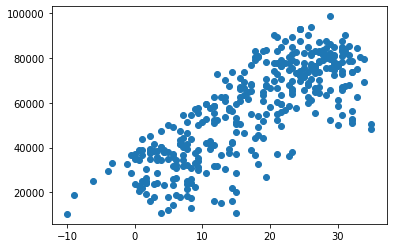

In [253]:
plt.figure()
plt.scatter(trips_per_day.TMAX, trips_per_day.count_trips)
plt.show()

In [258]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X = trips_per_day[['TMAX','PRCP', 'AWND', 'fsh']]
X['TxPrcp'] = X["TMAX"] * X['PRCP']
X['TxAwnd'] = X["TMAX"] * X['AWND']
X['WNDxPrcp'] = X["AWND"] * X['PRCP']
X['TxPrcpxAwnd'] = X["TMAX"] * X['PRCP'] * X['AWND']
y = trips_per_day[['count_trips']].to_numpy() #.reshape(-1,1)

num_list = [] #['TMAX','PRCP', 'AWND', 'TxPrcp', 'TxAwnd', 'WNDxPrcp', 'TxPrcpxAwnd']
pass_list = [] #['fsh']

preprocessor = ColumnTransformer(
    transformers=[('nums', StandardScaler(), num_list), 
                ('pass','passthrough', pass_list)])

pipe = Pipeline(steps=[('preprocessor',preprocessor),('lin_reg',LinearRegression())])

#Xtrain_norm = pipe.fit_transform(Xtrain)
#reg = LinearRegression().fit(Xtrain_norm,ytrain)

var_list = ['TMAX','PRCP', 'fsh', 'AWND', 'TxPrcp', 'TxAwnd', 'WNDxPrcp', 'TxPrcpxAwnd']
test_results = []
for var in var_list:
    if var == 'fsh': 
        pass_list.append(var)
    else: 
        num_list.append(var)
        
    a_list = []
    for i in range(10):
        Xtrain, Xtest, ytrain, ytest = train_test_split(X[num_list+pass_list],y, test_size=0.2, shuffle=True)
        
        pipe.fit(Xtrain,ytrain)

        #print(reg.coef_)

        #pipe.transform(Xtest)
        #Xtest_norm = pipe.transform(Xtest)

        y_pred = pipe.predict(Xtest)
        #rmse = np.sqrt(mean_squared_error(ytest, y_pred))
        r2_score_ = r2_score(ytest, y_pred)
        a_list.append(r2_score_)

    #for i in range(5):
    #    print(a_list[i])
    
    print(f'mean:{np.mean(a_list):.2f}, std:{np.std(a_list):.2f}')
#print(f"mean error:{round(np.sqrt(mean_2_err),2)}, r2 score:{round(r2_score_,2)}")



mean:0.60, std:0.07
mean:0.73, std:0.06
mean:0.71, std:0.03
mean:0.75, std:0.03
mean:0.72, std:0.04
mean:0.73, std:0.05
mean:0.73, std:0.05
mean:0.71, std:0.06


In [271]:
from sklearn.model_selection import cross_val_score

preprocessor = ColumnTransformer(
    transformers=[('nums', StandardScaler(), num_list), 
                ('pass','passthrough', pass_list)])

pipe = Pipeline(steps=[('preprocessor',preprocessor),('lin_reg',LinearRegression())])

var_list = ['TMAX','PRCP', 'fsh', 'AWND', 'TxPrcp', 'TxAwnd', 'WNDxPrcp', 'TxPrcpxAwnd']

test_results = []
num_list = []
pass_list = []
for var in var_list:
    if var == 'fsh': pass_list.append(var)
    else: num_list.append(var)
    
    #Xtr = Xtrain[num_list+pass_list]
    #Xts = Xtest[num_list+pass_list]
    
    #pipe.fit(Xtr,ytrain)
    #print(pipe.get_feature_names_out(input_features=None))
    # y_hat = pipe.predict(Xts)
    # r2 = r2_score(ytest,y_hat)
    
    X_full = X[num_list+pass_list]
    scores = cross_val_score(pipe, X_full, y, cv=10)
    
    test_results.append({var:[round(np.mean(scores),2), round(np.std(scores),2)]})
    
for i in range(len(var_list)):
    print(f'score: {test_results[i]}' ) 

score: {'TMAX': [-0.14, 0.41]}
score: {'PRCP': [-0.14, 0.41]}
score: {'fsh': [-0.14, 0.41]}
score: {'AWND': [-0.14, 0.41]}
score: {'TxPrcp': [-0.14, 0.41]}
score: {'TxAwnd': [-0.14, 0.41]}
score: {'WNDxPrcp': [-0.14, 0.41]}
score: {'TxPrcpxAwnd': [-0.14, 0.41]}


In [ ]:
# Most and least popular stations
start_station_no_rides = df.groupby(by=['start station name']).agg(
    count_trips = pd.NamedAgg(column='tripduration', aggfunc='count'),
    ss_lat = pd.NamedAgg(column='start station latitude', aggfunc=lambda x: pd.Series.mode(x)[0]),
    ss_long = pd.NamedAgg(column='start station longitude', aggfunc=lambda x: pd.Series.mode(x)[0])
)
start_station_no_rides = start_station_no_rides.sort_values('count_trips', ascending=True)

end_station_no_rides = df.groupby(by=['end station name']).agg(
    count_trips = pd.NamedAgg(column='tripduration', aggfunc='count'),
    ss_lat = pd.NamedAgg(column='end station latitude', aggfunc=lambda x: pd.Series.mode(x)[0]),
    ss_long = pd.NamedAgg(column='end station longitude', aggfunc=lambda x: pd.Series.mode(x)[0])
)

end_station_no_rides = end_station_no_rides.sort_values('count_trips', ascending=True)
display(end_station_no_rides.tail(10), start_station_no_rides.tail(10))

In [ ]:
import folium

m = folium.Map(location=[40.778969,-73.973747], zoom_start=12)

for i in range(5):
    # TODO add jitter
    t_long, t_lat = end_station_no_rides.iloc[i,2], end_station_no_rides.iloc[i,1]
    folium.CircleMarker(
    location=[t_lat, t_long],
    radius=1,
    color="red",
    fill=True,
    fill_color="red",
    ).add_to(m)
    
    te_long, te_lat = start_station_no_rides.iloc[-1-i,2], start_station_no_rides.iloc[-1-i,1]
    folium.CircleMarker(
    location=[te_lat, te_long],
    radius=1,
    color="blue",
    fill=True,
    fill_color="blue",
    ).add_to(m)

m

In [ ]:
# Check if day is lower than 7day ma
trips_per_day['7day ma'] = trips_per_day['count_trips'].rolling(7).mean()
trips_per_day['ma_diff'] = trips_per_day.count_trips - trips_per_day['7day ma']
display(trips_per_day.head(10))

In [ ]:
plt.figure(dpi=96)
plt.hlines(0,trips_per_day.index[0], trips_per_day.index[-1], color='black')
plt.scatter(trips_per_day.index, trips_per_day['ma_diff'], color='red')
plt.title('Number of Rides per Day of Year')
plt.xlabel('Day of Year')
plt.ylabel('No of Rides')
plt.show()

In [ ]:
# Bike study
# Bike utilization
bike_util = df.groupby(by=['bikeid']).aggregate(
    run_time = pd.NamedAgg(column='tripduration', aggfunc='sum')
)
bike_util = bike_util.sort_values('run_time', ascending=True)
bike_util['percent_run'] = bike_util['run_time']/(365*24*60)
print(bike_util.shape)
display(bike_util.head(5), bike_util.tail(5))

In [ ]:
plt.figure()
plt.hist(bike_util['percent_run'], bins=40)
plt.show()

In [ ]:
#del df
gc.collect()